# Project 207: Customer Shopping Behavior Clustering

This notebook builds customer segments with K-means using the cleaned H&M-style project data.

Workflow:
1. Load the cleaned customer, transaction, and article tables.
2. Engineer customer behavior features from purchase history.
3. Scale the features and compare candidate values of `k`.
4. Fit a final K-means model and assign each customer to a segment.
5. Profile each cluster and translate it into business-friendly customer groups.


## Setup

Load cleaned data into notebook



In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler



In [3]:
articles_clean_df = pd.read_csv("/Users/benwang/MIDS/ds207/project copy/articles_hm_cleaned.csv")
customers_clean_df = pd.read_csv("/Users/benwang/MIDS/ds207/project copy/customer_hm_cleaned.csv")
transactions_clean_df = pd.read_csv(
    "/Users/benwang/MIDS/ds207/project copy/transactions_hm_cleaned.csv",
    parse_dates=["t_dat"]
)

print("articles_clean_df:", articles_clean_df.shape)
print("customers_clean_df:", customers_clean_df.shape)
print("transactions_clean_df:", transactions_clean_df.shape)

display(articles_clean_df.head(2))
display(customers_clean_df.head(2))
display(transactions_clean_df.head(2))


articles_clean_df: (105542, 25)
customers_clean_df: (1048575, 6)
transactions_clean_df: (1040101, 5)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,NONE,49
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,NONE,25


,t_dat,customer_id,article_id,price,sales_channel_id
0,2019-11-05,3e2b60b679e62fb49516105b975560082922011dd752ec...,698328010,0.0169,2
1,2019-05-22,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,760597002,0.0339,2


## Feature Engineering

We cluster customers from their observed shopping behaviours.

The feature set combines:
- Purchase signals: recency, purchase frequency, and spending.
- Variety signals: number of unique products and product groups purchased.
- Channel preference: online versus in-store share.
- Time signals: customer lifetime and purchase rate.
- Customer attributes from the cleaned customer table.


In [5]:
tx = transactions_clean_df.merge(
    articles_clean_df[["article_id", "product_group_name"]],
    on="article_id",
    how="left"
)

analysis_date = tx["t_dat"].max() + pd.Timedelta(days=1)

customer_features = (
    tx.groupby("customer_id")
      .agg(
          total_transactions=("article_id", "count"),
          total_spend=("price", "sum"),
          avg_spend=("price", "mean"),
          spend_std=("price", "std"),
          unique_articles=("article_id", "nunique"),
          unique_product_groups=("product_group_name", "nunique"),
          online_share=("sales_channel_id", lambda s: (s == 2).mean()),
          store_share=("sales_channel_id", lambda s: (s == 1).mean()),
          first_purchase=("t_dat", "min"),
          last_purchase=("t_dat", "max"),
      )
      .reset_index()
)

customer_features["recency_days"] = (
    analysis_date - customer_features["last_purchase"]
).dt.days
customer_features["customer_lifetime_days"] = (
    customer_features["last_purchase"] - customer_features["first_purchase"]
).dt.days.clip(lower=0)
customer_features["purchase_rate"] = (
    customer_features["total_transactions"]
    / (customer_features["customer_lifetime_days"] + 1)
)
customer_features["group_diversity_ratio"] = (
    customer_features["unique_product_groups"]
    / customer_features["unique_articles"].clip(lower=1)
)
customer_features["spend_std"] = customer_features["spend_std"].fillna(0)

customer_features = customer_features.merge(
    customers_clean_df[
        [
            "customer_id",
            "age",
            "FN",
            "Active",
            "club_member_status",
            "fashion_news_frequency",
        ]
    ],
    on="customer_id",
    how="left",
)

customer_features["avg_transactions_per_month"] = (
    customer_features["total_transactions"]
    / ((customer_features["customer_lifetime_days"] / 30.0) + 1)
)

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())


Customer feature table shape: (458235, 21)


,customer_id,total_transactions,total_spend,avg_spend,spend_std,unique_articles,unique_product_groups,online_share,store_share,first_purchase,last_purchase,recency_days,customer_lifetime_days,purchase_rate,group_diversity_ratio,age,FN,Active,club_member_status,fashion_news_frequency,avg_transactions_per_month
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,2,0.1051,0.0525,0.0024,2,1,1.0000,0.0000,2019-05-25,2019-09-28,95,126,0.0157,0.5000,49.0000,0.0000,0.0000,ACTIVE,NONE,0.3846
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,6,0.1999,0.0333,0.0173,6,4,1.0000,0.0000,2019-05-07,2019-08-12,142,97,0.0612,0.6667,25.0000,0.0000,0.0000,ACTIVE,NONE,1.4173
2,000064249685c11552da43ef22a5030f35a147f723d5b0...,1,0.0424,0.0424,0.0000,1,1,1.0000,0.0000,2019-10-02,2019-10-02,91,0,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,1.0000
3,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,1,0.0254,0.0254,0.0000,1,1,1.0000,0.0000,2019-06-04,2019-06-04,211,0,1.0000,1.0000,20.0000,0.0000,0.0000,ACTIVE,NONE,1.0000
4,00007d2de826758b65a93dd24ce629ed66842531df6699...,7,0.3240,0.0463,0.0447,7,3,1.0000,0.0000,2019-01-06,2019-11-24,38,322,0.0217,0.4286,32.0000,1.0000,1.0000,ACTIVE,REGULARLY,0.5966


In [6]:
numeric_feature_cols = [
    "recency_days",
    "total_transactions",
    "total_spend",
    "avg_spend",
    "spend_std",
    "unique_articles",
    "unique_product_groups",
    "online_share",
    "store_share",
    "customer_lifetime_days",
    "purchase_rate",
    "group_diversity_ratio",
    "avg_transactions_per_month",
    "age",
    "FN",
    "Active",
]

categorical_feature_cols = [
    "club_member_status",
    "fashion_news_frequency",
]

model_input = customer_features[numeric_feature_cols + categorical_feature_cols].copy()

# KMeans cannot handle NaN values, so we impute any merge leftovers here.
model_input[numeric_feature_cols] = model_input[numeric_feature_cols].fillna(0)
for col in categorical_feature_cols:
    model_input[col] = model_input[col].fillna("UNKNOWN")

skewed_cols = [
    "total_transactions",
    "total_spend",
    "avg_spend",
    "spend_std",
    "unique_articles",
    "unique_product_groups",
    "customer_lifetime_days",
    "purchase_rate",
    "avg_transactions_per_month",
]

for col in skewed_cols:
    model_input[col] = np.log1p(model_input[col])

model_input = pd.get_dummies(
    model_input,
    columns=categorical_feature_cols,
    drop_first=False,
    dtype=int,
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_input)

print("Model input shape before scaling:", model_input.shape)
print("Scaled matrix shape:", X_scaled.shape)


Model input shape before scaling: (458235, 24)
Scaled matrix shape: (458235, 24)


In [7]:
customer_features[numeric_feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
recency_days,"458,235.0000",153.1695,100.5243,1.0000,65.0000,150.0000,227.0000,365.0000
total_transactions,"458,235.0000",2.2698,2.1438,1.0000,1.0000,1.0000,3.0000,59.0000
total_spend,"458,235.0000",0.0631,0.0724,0.0003,0.0220,0.0407,0.0762,1.9619
avg_spend,"458,235.0000",0.0274,0.0164,0.0003,0.0169,0.0254,0.0339,0.5068
spend_std,"458,235.0000",0.0064,0.0105,0.0000,0.0000,0.0000,0.0104,0.2829
unique_articles,"458,235.0000",2.2593,2.1250,1.0000,1.0000,1.0000,3.0000,59.0000
unique_product_groups,"458,235.0000",1.6360,0.9548,1.0000,1.0000,1.0000,2.0000,10.0000
online_share,"458,235.0000",0.6395,0.4459,0.0000,0.0000,1.0000,1.0000,1.0000
store_share,"458,235.0000",0.3605,0.4459,0.0000,0.0000,0.0000,1.0000,1.0000
customer_lifetime_days,"458,235.0000",65.2047,97.5502,0.0000,0.0000,0.0000,123.0000,364.0000


## Selecting the Number of Clusters

We compare several values of `k` using:
- Inertia for the elbow method.
- Silhouette score on a random sample for separation quality.

If the full customer base is large, silhouette is evaluated on a sample to keep runtime reasonable.


,k,inertia,silhouette_score
0,2,"8,717,566.6961",0.2332
1,3,"7,309,424.2086",0.2720
2,4,"6,366,346.6155",0.2705
3,5,"5,784,980.1117",0.2938
4,6,"5,288,664.1010",0.3146
5,7,"4,808,532.0741",0.3329
6,8,"4,350,466.8798",0.3331


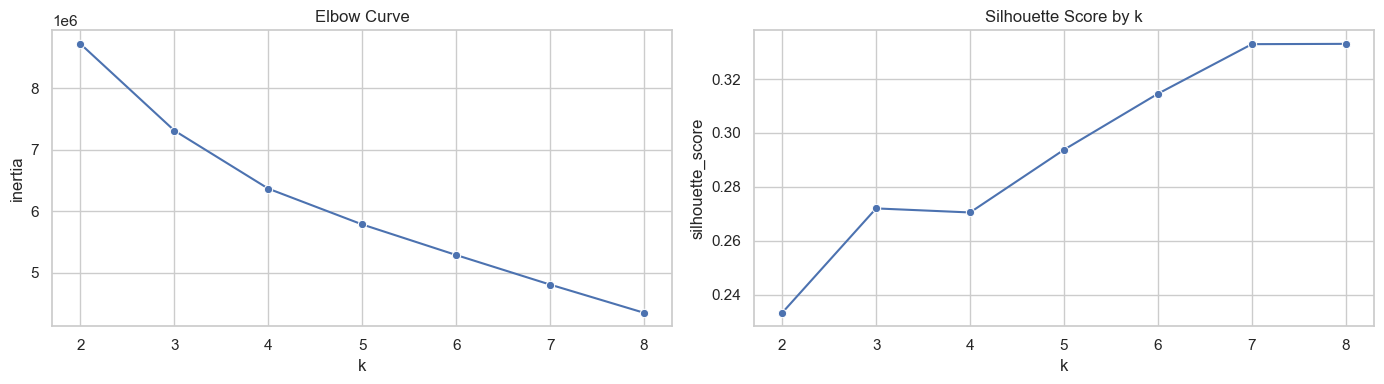

In [8]:
k_values = list(range(2, 9))
inertia_scores = []
silhouette_scores = []

rng = np.random.RandomState(42)
silhouette_sample_size = min(50000, len(model_input))
silhouette_idx = rng.choice(len(model_input), size=silhouette_sample_size, replace=False)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertia_scores.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled[silhouette_idx], labels[silhouette_idx])
    )

k_eval_df = pd.DataFrame(
    {
        "k": k_values,
        "inertia": inertia_scores,
        "silhouette_score": silhouette_scores,
    }
)

display(k_eval_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=k_eval_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Curve")

sns.lineplot(data=k_eval_df, x="k", y="silhouette_score", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()


In [9]:
final_k = 4

kmeans_model = KMeans(n_clusters=final_k, random_state=42, n_init=20)
customer_features["cluster"] = kmeans_model.fit_predict(X_scaled)

customer_features["cluster"].value_counts().sort_index()


cluster
0    117795
1    137798
2     98662
3    103980
Name: count, dtype: int64

In [11]:
# pca = PCA(n_components=2, random_state=42)
# customer_embeddings = pca.fit_transform(X_scaled)

# pca_plot_df = pd.DataFrame(
#     {
#         "pc1": customer_embeddings[:, 0],
#         "pc2": customer_embeddings[:, 1],
#         "cluster": customer_features["cluster"],
#     }
# )

# plt.figure(figsize=(10, 6))
# sns.scatterplot(
#     data=pca_plot_df.sample(min(40000, len(pca_plot_df)), random_state=42),
#     x="pc1",
#     y="pc2",
#     hue="cluster",
#     palette="tab10",
#     alpha=0.6,
#     s=18,
# )
# plt.title("Customer Clusters in PCA Space")
# plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
# plt.show()


## Cluster Profiles

This section summarizes each segment in the original feature space so the clusters can be interpreted in business terms.


In [12]:
cluster_profile = (
    customer_features.groupby("cluster")[numeric_feature_cols]
    .mean()
    .round(3)
    .sort_index()
)

cluster_sizes = (
    customer_features["cluster"]
    .value_counts()
    .sort_index()
    .rename("customer_count")
    .to_frame()
)

cluster_summary = cluster_sizes.join(cluster_profile)
display(cluster_summary)


,customer_count,recency_days,total_transactions,total_spend,avg_spend,spend_std,unique_articles,unique_product_groups,online_share,store_share,customer_lifetime_days,purchase_rate,group_diversity_ratio,avg_transactions_per_month,age,FN,Active
cluster,,,,,,,,,,,,,,,,,
0,117795,88.8520,4.5530,0.1340,0.0300,0.0160,4.5270,2.6670,0.7170,0.2830,185.9200,0.0330,0.6720,0.7040,36.1810,0.3600,0.3540
1,137798,188.1030,1.2530,0.0330,0.0270,0.0020,1.2490,1.1430,0.6380,0.3620,3.1680,1.0690,0.9550,1.1710,36.0520,0.0000,0.0000
2,98662,158.9270,1.8580,0.0490,0.0270,0.0050,1.8510,1.4860,0.6260,0.3740,51.5990,0.7370,0.8890,0.9960,NaN,NaN,NaN
3,103980,174.2740,1.4210,0.0360,0.0260,0.0030,1.4170,1.2630,0.5670,0.4330,23.5740,0.8700,0.9350,1.0610,36.9330,0.9990,0.9830


In [14]:
cluster_category_mix = (
    tx.merge(customer_features[["customer_id", "cluster"]], on="customer_id", how="left")
      .groupby(["cluster", "product_group_name"])
      .size()
      .rename("transactions")
      .reset_index()
)

top_categories_by_cluster = (
    cluster_category_mix.sort_values(["cluster", "transactions"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
)

display(top_categories_by_cluster)


,cluster,product_group_name,transactions
6,0,Garment Upper body,213684
5,0,Garment Lower body,121259
4,0,Garment Full body,64708
12,0,Swimwear,41519
13,0,Underwear,38587
21,1,Garment Upper body,66425
20,1,Garment Lower body,37359
26,1,Swimwear,17968
19,1,Garment Full body,17382
27,1,Underwear,14863


In [15]:
ranking_table = cluster_summary.copy()

ranking_table["value_score"] = (
    ranking_table["total_spend"].rank(pct=True)
    + ranking_table["total_transactions"].rank(pct=True)
    + ranking_table["purchase_rate"].rank(pct=True)
    - ranking_table["recency_days"].rank(pct=True)
)

ranking_table = ranking_table.sort_values("value_score", ascending=False)

default_segment_names = [
    "High-Value Loyalists",
    "Steady Omnichannel Shoppers",
    "Occasional Customers",
    "At-Risk / One-Time Buyers",
]

cluster_name_map = {
    cluster_id: default_segment_names[idx]
    if idx < len(default_segment_names)
    else f"Segment {idx + 1}"
    for idx, cluster_id in enumerate(ranking_table.index.tolist())
}

customer_features["segment_name"] = customer_features["cluster"].map(cluster_name_map)
cluster_summary["segment_name"] = cluster_summary.index.map(cluster_name_map)

display(cluster_summary[["segment_name", "customer_count"] + numeric_feature_cols])


,segment_name,customer_count,recency_days,total_transactions,total_spend,avg_spend,spend_std,unique_articles,unique_product_groups,online_share,store_share,customer_lifetime_days,purchase_rate,group_diversity_ratio,avg_transactions_per_month,age,FN,Active
cluster,,,,,,,,,,,,,,,,,,
0,High-Value Loyalists,117795,88.8520,4.5530,0.1340,0.0300,0.0160,4.5270,2.6670,0.7170,0.2830,185.9200,0.0330,0.6720,0.7040,36.1810,0.3600,0.3540
1,At-Risk / One-Time Buyers,137798,188.1030,1.2530,0.0330,0.0270,0.0020,1.2490,1.1430,0.6380,0.3620,3.1680,1.0690,0.9550,1.1710,36.0520,0.0000,0.0000
2,Steady Omnichannel Shoppers,98662,158.9270,1.8580,0.0490,0.0270,0.0050,1.8510,1.4860,0.6260,0.3740,51.5990,0.7370,0.8890,0.9960,NaN,NaN,NaN
3,Occasional Customers,103980,174.2740,1.4210,0.0360,0.0260,0.0030,1.4170,1.2630,0.5670,0.4330,23.5740,0.8700,0.9350,1.0610,36.9330,0.9990,0.9830


In [16]:
output_path = "/Users/benwang/MIDS/ds207/project copy/customer_clusters_kmeans.csv"
profile_path = "/Users/benwang/MIDS/ds207/project copy/customer_cluster_profiles.csv"

customer_features.to_csv(output_path, index=False)
cluster_summary.to_csv(profile_path, index=True)

print(f"Saved customer-level clusters to: {output_path}")
print(f"Saved cluster profiles to: {profile_path}")


Saved customer-level clusters to: /Users/benwang/MIDS/ds207/project copy/customer_clusters_kmeans.csv
Saved cluster profiles to: /Users/benwang/MIDS/ds207/project copy/customer_cluster_profiles.csv


## Suggested Interpretation

After you run the notebook, use the cluster profile table to write a short business narrative for each segment:
- Which clusters are the most valuable?
- Which clusters appear inactive or churn-risk?
- Which clusters prefer online versus store shopping?
- Which clusters have narrow versus broad category diversity?

If the elbow and silhouette plots suggest a different `k`, change `final_k` and rerun the modeling and profiling cells.


In [17]:
# Cluster ranking table for business interpretation
cluster_insights = cluster_summary.copy()

cluster_insights["value_score"] = (
    cluster_insights["total_spend"].rank(pct=True)
    + cluster_insights["total_transactions"].rank(pct=True)
    + cluster_insights["purchase_rate"].rank(pct=True)
    - cluster_insights["recency_days"].rank(pct=True)
)

cluster_insights["churn_risk_score"] = (
    cluster_insights["recency_days"].rank(pct=True)
    - cluster_insights["total_transactions"].rank(pct=True)
    - cluster_insights["purchase_rate"].rank(pct=True)
)

cluster_insights["channel_preference"] = np.where(
    cluster_insights["online_share"] > cluster_insights["store_share"],
    "Online",
    "Store"
)

cluster_insights["diversity_type"] = np.where(
    cluster_insights["group_diversity_ratio"] >= cluster_insights["group_diversity_ratio"].median(),
    "Broad category diversity",
    "Narrow category diversity"
)

display(cluster_insights.sort_index())


,customer_count,recency_days,total_transactions,total_spend,avg_spend,spend_std,unique_articles,unique_product_groups,online_share,store_share,customer_lifetime_days,purchase_rate,group_diversity_ratio,avg_transactions_per_month,age,FN,Active,segment_name,value_score,churn_risk_score,channel_preference,diversity_type
cluster,,,,,,,,,,,,,,,,,,,,,,
0,117795,88.8520,4.5530,0.1340,0.0300,0.0160,4.5270,2.6670,0.7170,0.2830,185.9200,0.0330,0.6720,0.7040,36.1810,0.3600,0.3540,High-Value Loyalists,2.0000,-1.0000,Online,Narrow category diversity
1,137798,188.1030,1.2530,0.0330,0.0270,0.0020,1.2490,1.1430,0.6380,0.3620,3.1680,1.0690,0.9550,1.1710,36.0520,0.0000,0.0000,At-Risk / One-Time Buyers,0.5000,-0.2500,Online,Broad category diversity
2,98662,158.9270,1.8580,0.0490,0.0270,0.0050,1.8510,1.4860,0.6260,0.3740,51.5990,0.7370,0.8890,0.9960,NaN,NaN,NaN,Steady Omnichannel Shoppers,1.5000,-0.7500,Online,Narrow category diversity
3,103980,174.2740,1.4210,0.0360,0.0260,0.0030,1.4170,1.2630,0.5670,0.4330,23.5740,0.8700,0.9350,1.0610,36.9330,0.9990,0.9830,Occasional Customers,1.0000,-0.5000,Online,Broad category diversity


In [18]:
# 1. Which clusters are the most valuable?
most_valuable_clusters = cluster_insights.sort_values("value_score", ascending=False)[
    ["customer_count", "total_spend", "total_transactions", "purchase_rate", "recency_days", "value_score"]
]

print("Most valuable clusters:")
display(most_valuable_clusters)


Most valuable clusters:


,customer_count,total_spend,total_transactions,purchase_rate,recency_days,value_score
cluster,,,,,,
0,117795,0.1340,4.5530,0.0330,88.8520,2.0000
2,98662,0.0490,1.8580,0.7370,158.9270,1.5000
3,103980,0.0360,1.4210,0.8700,174.2740,1.0000
1,137798,0.0330,1.2530,1.0690,188.1030,0.5000


In [19]:
# 2. Which clusters appear inactive or churn-risk?
churn_risk_clusters = cluster_insights.sort_values("churn_risk_score", ascending=False)[
    ["customer_count", "recency_days", "total_transactions", "purchase_rate", "total_spend", "churn_risk_score"]
]

print("Most churn-risk / inactive clusters:")
display(churn_risk_clusters)


Most churn-risk / inactive clusters:


,customer_count,recency_days,total_transactions,purchase_rate,total_spend,churn_risk_score
cluster,,,,,,
1,137798,188.1030,1.2530,1.0690,0.0330,-0.2500
3,103980,174.2740,1.4210,0.8700,0.0360,-0.5000
2,98662,158.9270,1.8580,0.7370,0.0490,-0.7500
0,117795,88.8520,4.5530,0.0330,0.1340,-1.0000


In [20]:
# 3. Which clusters prefer online versus store shopping?
channel_view = cluster_insights[
    ["customer_count", "online_share", "store_share", "channel_preference"]
].sort_values("online_share", ascending=False)

print("Channel preference by cluster:")
display(channel_view)


Channel preference by cluster:


,customer_count,online_share,store_share,channel_preference
cluster,,,,
0,117795,0.7170,0.2830,Online
1,137798,0.6380,0.3620,Online
2,98662,0.6260,0.3740,Online
3,103980,0.5670,0.4330,Online


In [21]:
# 4. Which clusters have narrow versus broad category diversity?
diversity_view = cluster_insights[
    ["customer_count", "unique_product_groups", "group_diversity_ratio", "diversity_type"]
].sort_values("group_diversity_ratio", ascending=False)

print("Category diversity by cluster:")
display(diversity_view)


Category diversity by cluster:


,customer_count,unique_product_groups,group_diversity_ratio,diversity_type
cluster,,,,
1,137798,1.1430,0.9550,Broad category diversity
3,103980,1.2630,0.9350,Broad category diversity
2,98662,1.4860,0.8890,Narrow category diversity
0,117795,2.6670,0.6720,Narrow category diversity
